In [ ]:
# PET Image Classification for Lung Cancer Subtypes

This project processes PET scan DICOM images of lung cancer patients and extracts **radiomics-style features** (intensity, texture, shape) to classify tumor subtypes:

- Adenocarcinoma  
- Squamous Cell Carcinoma  
- Small Cell Carcinoma  
- Large Cell Carcinoma  

The workflow includes:
1. Data loading & normalization  
2. Feature extraction  
3. Train/test split & cross-validation  
4. Random Forest classifier  
5. Performance evaluation (classification report, confusion matrix, ROC curves, feature importance)  

> **Note:** ROI segmentation is not used to avoid misleading visualizations. Sample images are shown for reference.

In [2]:
#2️⃣ Data Loading & Feature Extraction
import os
import random
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import label, regionprops

BASE_PATH = "/Users/Marcin_1/Desktop/PET/imbalanced_dataset/"

def normalize(img):
    if img.max() > img.min():
        return (img - img.min()) / (img.max() - img.min())
    return img

def intensity_features(img):
    return {
        "mean": np.mean(img),
        "std": np.std(img),
        "max": np.max(img),
        "p10": np.percentile(img, 10),
        "p90": np.percentile(img, 90)
    }

def texture_features(img):
    if img.ndim == 3:
        slices = img
    else:
        slices = [img]
    
    contrasts, homogeneities, energies = [], [], []
    for sl in slices:
        if np.std(sl) == 0:
            continue
        sl_norm = normalize(sl)
        sl_uint8 = (sl_norm * 255).astype(np.uint8)
        glcm = graycomatrix(sl_uint8, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrasts.append(graycoprops(glcm, 'contrast')[0,0])
        homogeneities.append(graycoprops(glcm, 'homogeneity')[0,0])
        energies.append(graycoprops(glcm, 'energy')[0,0])
    
    return {
        "contrast": np.mean(contrasts) if contrasts else 0,
        "homogeneity": np.mean(homogeneities) if homogeneities else 0,
        "energy": np.mean(energies) if energies else 0
    }

def shape_features(img):
    threshold = np.percentile(img, 90)
    roi = img > threshold
    labeled = label(roi)
    regions = regionprops(labeled)
    if len(regions) == 0:
        return {"volume": 0}
    largest = max(regions, key=lambda r: r.area)
    return {"volume": largest.area}

# Load data
data = []
for label_name in os.listdir(BASE_PATH):
    folder = os.path.join(BASE_PATH, label_name)
    if not os.path.isdir(folder):
        continue
    for file in os.listdir(folder):
        if not file.endswith(".dcm"):
            continue
        ds = pydicom.dcmread(os.path.join(folder, file))
        img = ds.pixel_array.astype(float)
        if not np.any(img):
            continue
        img = normalize(img)
        feats = {}
        feats.update(intensity_features(img))
        feats.update(texture_features(img))
        feats.update(shape_features(img))
        feats["label"] = label_name
        feats["img"] = img  # optional for sample visualization
        data.append(feats)

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (18500, 11)


,mean,std,max,p10,p90,contrast,homogeneity,energy,volume,label,img
0,0.113629,0.134019,1.0,0.000000,0.302809,110.710058,0.229451,0.115686,3031.0,Adenocarcinoma,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,0.138570,0.131828,1.0,0.000000,0.312951,202.671875,0.183776,0.098907,3423.0,Adenocarcinoma,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,0.254023,0.241640,1.0,0.011000,0.543500,34.597018,0.523552,0.107884,11788.0,Adenocarcinoma,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,0.555045,0.306510,1.0,0.000000,0.805202,76.536242,0.753481,0.234635,5338.0,Adenocarcinoma,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,0.210226,0.158055,1.0,0.002923,0.369276,97.941066,0.186275,0.056924,3242.0,Adenocarcinoma,"[[0.005521273140630075, 0.0022734654108476776,..."


In [4]:
#3️⃣ Train/Test Split
from sklearn.model_selection import train_test_split

X = df.drop(["label", "img"], axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 14800
Testing samples: 3700


In [12]:
#4️⃣ Random Forest & Cross-Validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv)

print("CV Scores:", cv_scores)
print("Mean CV:", np.mean(cv_scores))

# Train final model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

CV Scores: [0.8027027  0.79324324 0.80033784 0.80439189 0.80709459]
Mean CV: 0.8015540540540542


In [7]:
#5️⃣ Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                         precision    recall  f1-score   support

         Adenocarcinoma       0.82      0.95      0.88      2000
   Large Cell Carcinoma       0.78      0.39      0.52       100
   Small Cell Carcinoma       0.82      0.62      0.70       600
Squamous Cell Carcinoma       0.81      0.70      0.75      1000

               accuracy                           0.81      3700
              macro avg       0.81      0.66      0.71      3700
           weighted avg       0.81      0.81      0.81      3700



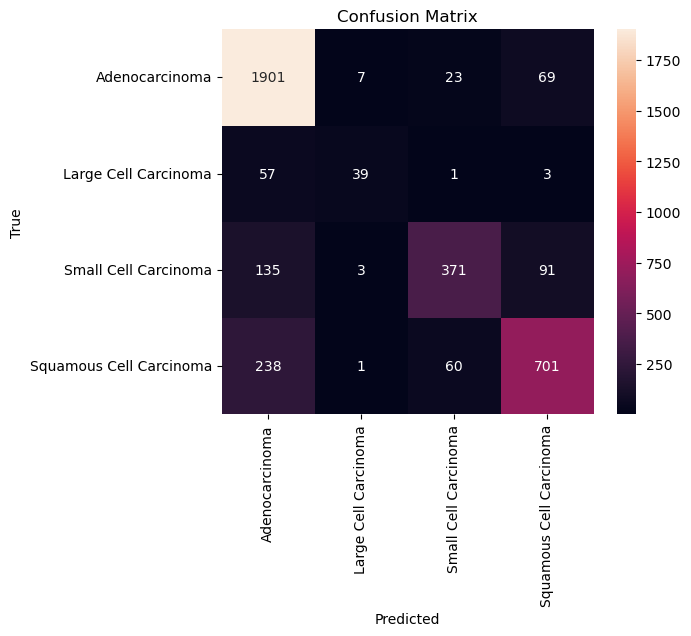

In [8]:
#6️⃣ Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

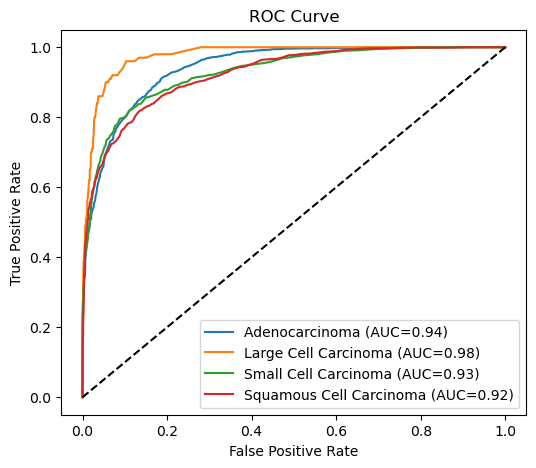

In [9]:
#7️⃣ ROC Curves
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=model.classes_)
y_score = model.predict_proba(X_test)

plt.figure(figsize=(6,5))
for i in range(len(model.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"{model.classes_[i]} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

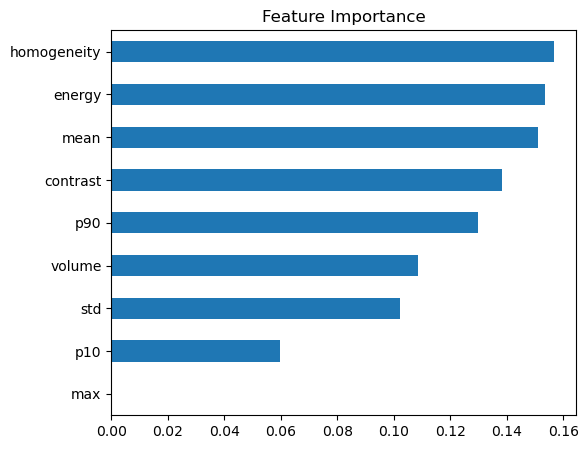

In [10]:
#8️⃣ Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(6,5))
plt.title("Feature Importance")
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

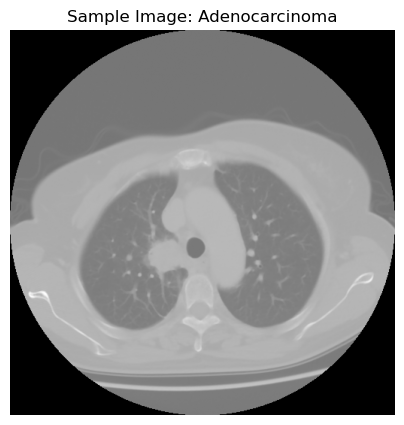

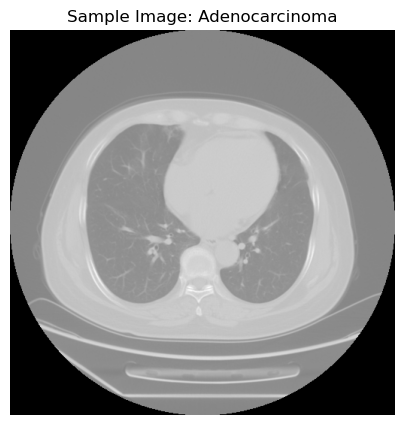

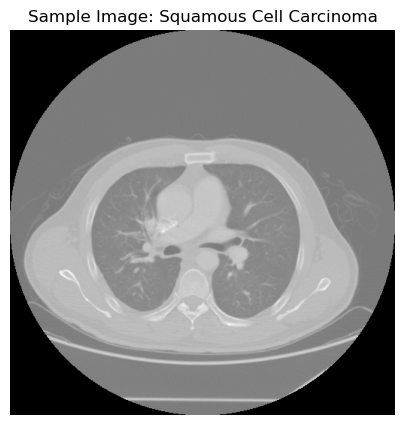

In [19]:
#9️⃣ Sample PET Images
import random
sample_indices = random.sample(range(len(df)), 3)
for i, idx in enumerate(sample_indices):
    sample = df.iloc[idx]["img"]
    plt.figure(figsize=(5,5))
    
    if sample.ndim == 3:
        mid_slice = sample.shape[0] // 2
        plt.imshow(sample[mid_slice], cmap="gray")
    else:
        plt.imshow(sample, cmap="gray")
    
    plt.title(f"Sample Image: {df.iloc[idx]['label']}")
    plt.axis("off")
    
    plt.savefig(f"sample_{i}.png", dpi=300, bbox_inches="tight")
    plt.show()